In [1]:
# Standard library
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Local modules
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from ML_libs.data_wrangling import condense_and_join
from ML_libs.plotters import plotters


Before the exploratory data analysis, we start with an workflow example where:
1. We merge the results from each experiment
2. Join the results from different experiments 

Set path to experimental data and print available folders:

In [2]:
# Path to raw LIBS spectra (relative to the notebooks/ folder)
path_to_raw = str(project_root / "raw_data")

list_of_experiments = os.listdir(path_to_raw)
print(f"The experiments available are:\n")
for i in list_of_experiments: print(i)

The experiments available are:

N1-Muestra 1-log_24jul.24_161346-ascii
F1-muestra 1-log_09ago.24_112021-ascii
N6-muestra 1-log_23jul.24_163256-ascii
N2-muestra 1-log_08ago.24_112324-ascii
N3-muestra1-log_24jul.24_152442-ascii
F1-muestra 1-log_09ago.24_111305-ascii
N5-muestra 1-log_08ago.24_104941-ascii


Select which experiments you want to merge (or condense)

$\cdot$ Choose a discrete set of experiments :

```python 
dat_to_con = ["F1-muestra 1-log_09ago.24_111305-ascii",
              "N1-Muestra 1-log_24jul.24_161346-ascii"]
```

$\cdot$ Or the whole set of experiments: 

```python 
data_to_con = list_of_experiments
```


In [9]:
#data_to_con = list_of_experiments
data_to_con=[
    "N1-Muestra 1-log_24jul.24_161346-ascii",
    "F1-muestra 1-log_09ago.24_112021-ascii",
    "N6-muestra 1-log_23jul.24_163256-ascii",
    "N2-muestra 1-log_08ago.24_112324-ascii",
    "N3-muestra1-log_24jul.24_152442-ascii",
    "N5-muestra 1-log_08ago.24_104941-ascii",
]

Set path to folder to store results

In [7]:
# Path to store generated figures
path_to_res = str(project_root / "results")


Call condense function:

"This function takes a list of experiments and condense all 
 the spectra of that experiment in a single csv. This csv is stored in a experiment/condense"

In [10]:
seg = "Merge0" # part of the spectrum; "Merge_0" or name of spectrometer
data, condense_data = condense_and_join.condense(data_to_con, path_to_raw, seg, test=True)
#condense_and_join.condense(data_to_con, path_to_raw, seg, test=False)

/home/matias/Documents/ML-libs/raw_data/N1-Muestra 1-log_24jul.24_161346-ascii
/home/matias/Documents/ML-libs/raw_data/F1-muestra 1-log_09ago.24_112021-ascii
/home/matias/Documents/ML-libs/raw_data/N6-muestra 1-log_23jul.24_163256-ascii
/home/matias/Documents/ML-libs/raw_data/N2-muestra 1-log_08ago.24_112324-ascii
/home/matias/Documents/ML-libs/raw_data/N3-muestra1-log_24jul.24_152442-ascii
/home/matias/Documents/ML-libs/raw_data/N5-muestra 1-log_08ago.24_104941-ascii


Then we join the condensed data of each experiment in a single df with join_data

In [11]:
df = condense_and_join.join_data(path_to_raw, data_to_con, seg="Merge0")

In [13]:
df.sample(5)

,211.53,211.62,211.72,211.81,211.91,212.0,212.09,212.19,212.28,212.38,...,636.61,636.66,636.71,636.75,636.8,636.85,636.9,636.94,file,experiment
499,223.450,219.450,209.45000,250.450,189.450,212.450,246.450,225.450,226.450,213.450,...,375.17499,428.17499,371.17499,387.17499,403.17499,374.17499,418.17499,384.17499,log152528540_Merge0.TXT,N3-muestra1-log_24jul.24_152442-ascii
61,209.175,232.175,202.17500,221.175,190.175,210.175,221.175,246.175,216.175,194.175,...,355.47501,400.47501,347.47501,396.47501,455.47501,409.47501,418.47501,393.47501,log161527186_Merge0.TXT,N1-Muestra 1-log_24jul.24_161346-ascii
48,214.175,214.175,262.17499,224.175,196.175,250.175,240.175,204.175,233.175,207.175,...,370.87500,407.87500,398.87500,383.87500,408.87500,399.87500,408.87500,419.87500,log161421465_Merge0.TXT,N1-Muestra 1-log_24jul.24_161346-ascii
318,183.175,233.175,240.17500,233.175,213.175,209.175,226.175,216.175,212.175,252.175,...,371.57501,391.57501,388.57501,409.57501,391.57501,402.57501,408.57501,396.57501,log112454629_Merge0.TXT,N2-muestra 1-log_08ago.24_112324-ascii
398,196.050,244.050,203.05000,231.050,192.050,228.050,238.050,204.050,236.050,230.050,...,377.45001,400.45001,354.45001,357.45001,414.45001,381.45001,402.45001,395.45001,log112555546_Merge0.TXT,N2-muestra 1-log_08ago.24_112324-ascii


Plot some randomly selected spectra, and store:

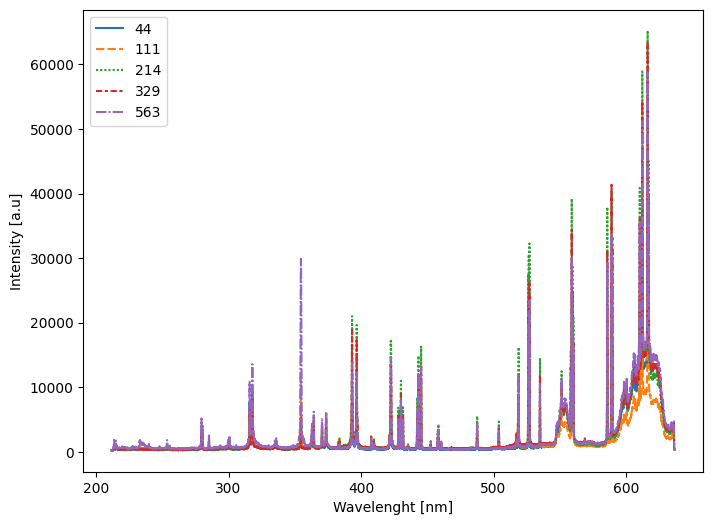

In [14]:
plotters.PlotOverlap_random(df.drop(columns=["file", "experiment"]), path_to_res, num=5, filename= "Some_libs_spectra")

Zoom in :

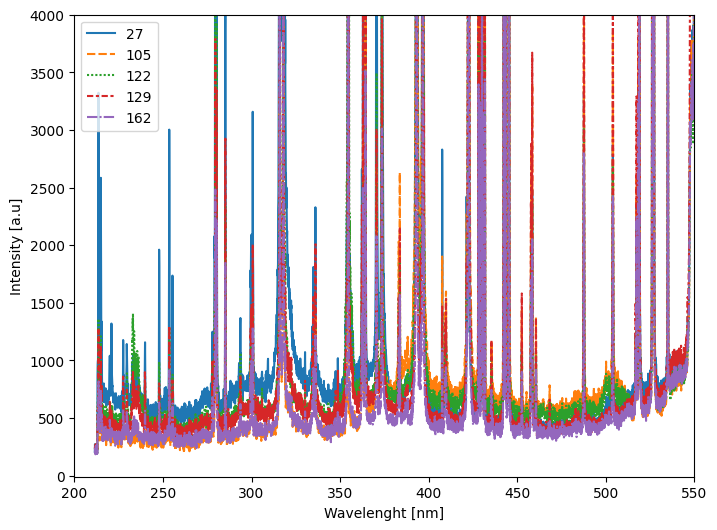

In [9]:
plotters.Plot_zoom(df.drop(columns=["file", "experiment"]), path_to_res, ymax = 4000, random = True,  filename= "Zoom_in_random")

Normalize spectra and remove constant baseline (only type for the moment):

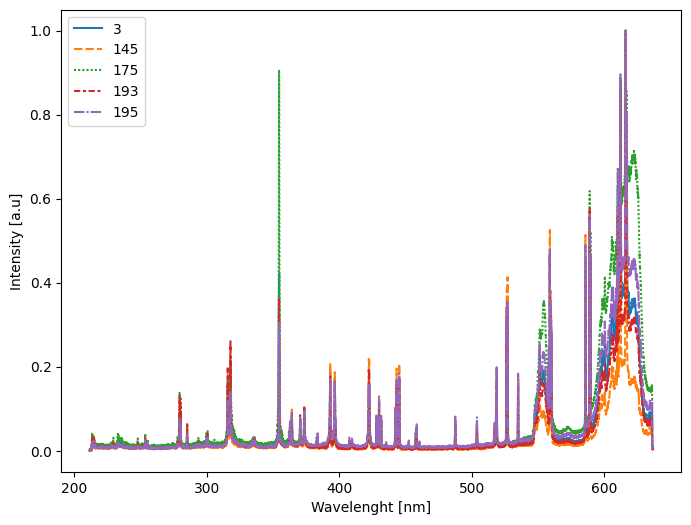

In [28]:
df_norm = condense_and_join.normalize_dataframe(df)
plotters.PlotOverlap_random(df_norm.drop(columns=["file", "experiment"]), path_to_res, num=5, filename= "norm_spectra")

In [29]:
df_base = condense_and_join.remove_baseline(df_norm, type="constant", level=0.01)



Compare spctra with and without baseline substraction

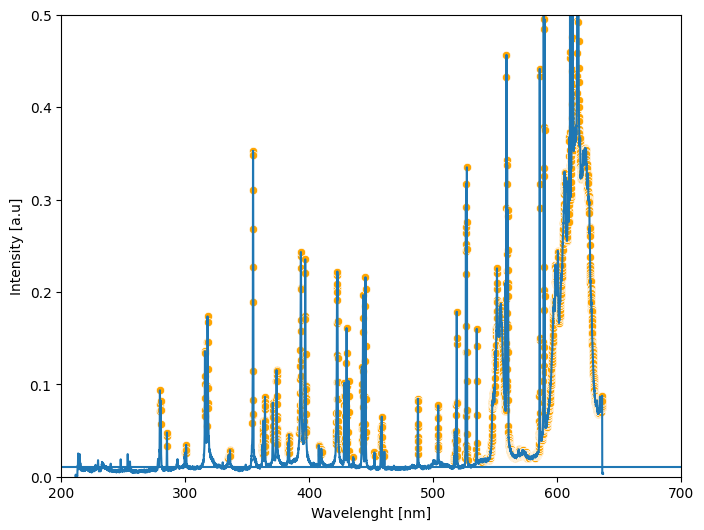

In [30]:
plotters.Plot_CompareBaseline(df_norm.drop(columns=["file", "experiment"]), 
                              df_base.drop(columns=["file", "experiment"]), 
                              path_to_res, iloc=6, level=0.01, 
                              filename= "WhitBase",
                              xmin=200, xmax =700,
                              ymin=0, ymax= 0.5)

If we want to exclude a part of the spectra:

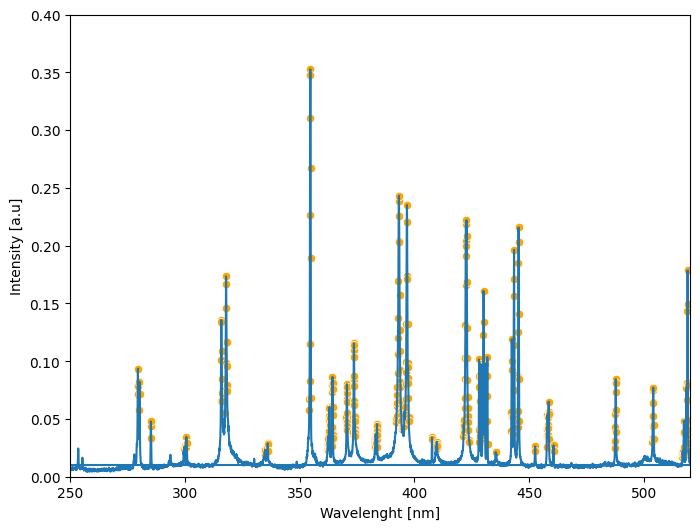

In [31]:
df_norm_zoom = condense_and_join.select_region(df_norm, xmin=250, xmax=520)
df_base_zoom = condense_and_join.remove_baseline(df_norm_zoom, type="constant", level=0.01)
plotters.Plot_CompareBaseline(df_norm_zoom.drop(columns=["file", "experiment"]), 
                              df_base_zoom.drop(columns=["file", "experiment"]), 
                              path_to_res, iloc=6, level=0.01, 
                              filename= "WhitBase_zoom",
                              xmin=250, xmax =520,
                              ymin=0, ymax= 0.4)

In [32]:
df_base_zoom.head(2)

,279.46,279.55,279.64,280.16,280.25,280.34,285.14,285.23,285.32,299.72,...,518.85,518.93,519.0,519.08,519.15,519.23,519.3,519.38,file,experiment
0,0.019998,0.026624,0.021090,0.016432,0.024933,0.022104,0.028069,0.029498,0.016109,0.015110,...,0.155391,0.198908,0.167566,0.083898,0.040258,0.028437,0.021428,0.021028,log112123796_Merge0.TXT,F1-muestra 1-log_09ago.24_112021-ascii
1,0.020099,0.026864,0.022148,0.017512,0.025093,0.023362,0.020636,0.020895,0.013034,0.012616,...,0.137893,0.170249,0.143843,0.072602,0.034435,0.025281,0.016864,0.018655,log112226318_Merge0.TXT,F1-muestra 1-log_09ago.24_112021-ascii


Plot the average of each experiemnt  

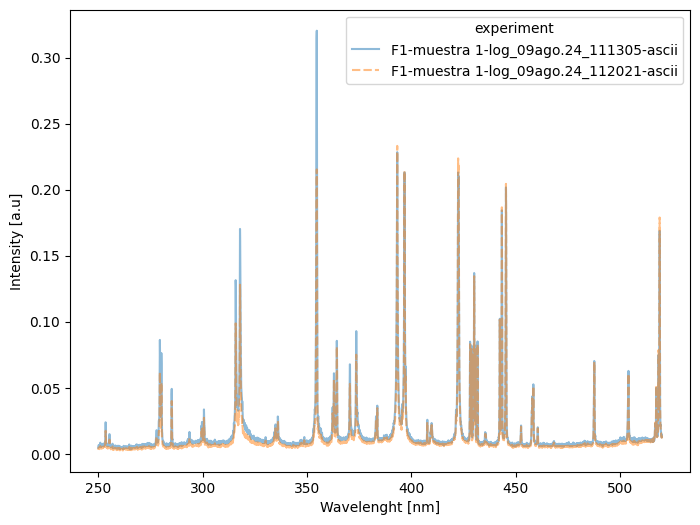

In [33]:
plotters.Plot_groupBy_mean(df_norm_zoom, path_to_res, alpha=0.5, filename="Average_groupby")

Make a zoom with average spectra $\pm$ std for each experiment

This may be useful to compare individual transitions 

this may take a bit


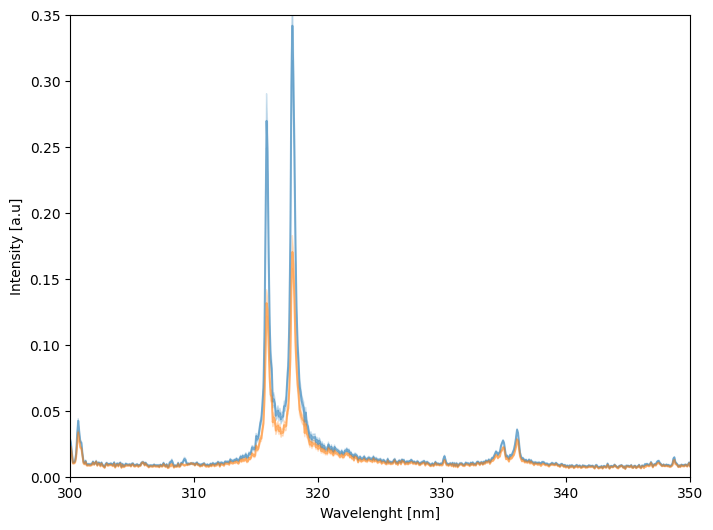

In [14]:
plotters.Plot_with_std(df_norm_zoom, path_to_res, alpha=0.5, filename="zoomWithStd",
            xmin=300, xmax =350,
            ymin=0, ymax= 0.35) 
    